In [1]:
import numpy as np
import os
import torch
from matplotlib import pyplot as plt

In [2]:
data_dir  = "/mnt/nas/home/genghaoyu/OR/PTO/Rethink1.0/openpto/data/shortestpath/12x12/"
split_prefix="test"
data_suffix="maps"
inputs = np.load(
    os.path.join(data_dir, split_prefix + "_" + data_suffix + ".npy")
        ).astype(np.float32)
labels = np.load(
    os.path.join(data_dir, split_prefix + "_shortest_paths.npy")
)
true_weights = np.load(
    os.path.join(data_dir, split_prefix + "_vertex_weights.npy")
)


In [3]:
labels

array([[[1, 0, 0, ..., 0, 0, 0],
        [1, 0, 0, ..., 0, 0, 0],
        [1, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 1, 0, 0],
        [0, 0, 0, ..., 0, 1, 0],
        [0, 0, 0, ..., 0, 0, 1]],

       [[1, 1, 1, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 1, 0, 0],
        [0, 0, 0, ..., 0, 1, 0],
        [0, 0, 0, ..., 0, 0, 1]],

       [[1, 1, 1, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 1, 0, 0],
        [0, 0, 0, ..., 0, 1, 0],
        [0, 0, 0, ..., 0, 0, 1]],

       ...,

       [[1, 0, 0, ..., 0, 0, 0],
        [0, 1, 0, ..., 0, 0, 0],
        [0, 0, 1, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 1, 0],
        [0, 0, 0, ..., 0, 1, 0],
        [0, 0, 0, ..., 0, 0, 1]],

       [[1, 1, 0, ..., 0, 0, 0],
        [0, 0, 1, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

### plot raw image

In [4]:
def plot(im):
    fig, ax = plt.subplots(1,1, figsize=(3,3))
    ax.imshow(im.astype(np.uint8))

(None, None, None, None)

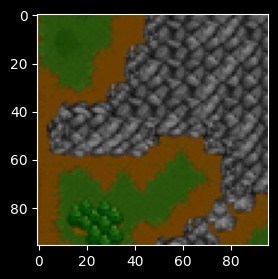

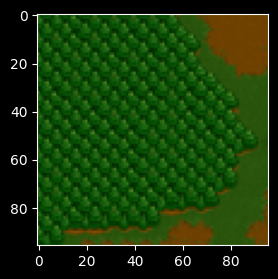

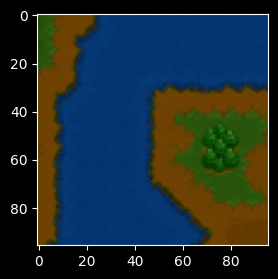

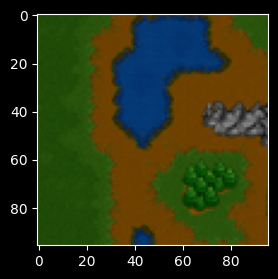

In [5]:
plot(inputs[0]),plot(inputs[1]), plot(inputs[2]),plot(inputs[3])

In [3]:
labels[0], labels[0].shape


(array([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]], dtype=uint8),
 (12, 12))

In [4]:
true_weights[0], true_weights[0].shape

(array([[0.8, 0.8, 0.8, 0.8, 1.2, 1.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2],
        [0.8, 0.8, 0.8, 0.8, 1.2, 1.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2],
        [0.8, 0.8, 0.8, 1.2, 1.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2],
        [1.2, 0.8, 0.8, 1.2, 1.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2],
        [1.2, 1.2, 1.2, 1.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2],
        [1.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2],
        [1.2, 9.2, 9.2, 9.2, 9.2, 9.2, 1.2, 1.2, 1.2, 9.2, 9.2, 9.2],
        [1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 0.8, 1.2, 1.2, 9.2, 9.2],
        [1.2, 0.8, 0.8, 1.2, 0.8, 1.2, 0.8, 0.8, 0.8, 1.2, 9.2, 9.2],
        [1.2, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 1.2, 1.2, 9.2, 1.2],
        [1.2, 0.8, 5.3, 5.3, 0.8, 0.8, 0.8, 1.2, 1.2, 9.2, 1.2, 1.2],
        [1.2, 0.8, 0.8, 5.3, 0.8, 1.2, 1.2, 1.2, 9.2, 1.2, 1.2, 0.8]],
       dtype=float16),
 (12, 12))

In [7]:
idx=0
true_weights[idx], true_weights[idx].sum(0), true_weights[idx].sum(1)

(array([[0.8, 0.8, 0.8, 0.8, 1.2, 1.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2],
        [0.8, 0.8, 0.8, 0.8, 1.2, 1.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2],
        [0.8, 0.8, 0.8, 1.2, 1.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2],
        [1.2, 0.8, 0.8, 1.2, 1.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2],
        [1.2, 1.2, 1.2, 1.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2],
        [1.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2, 9.2],
        [1.2, 9.2, 9.2, 9.2, 9.2, 9.2, 1.2, 1.2, 1.2, 9.2, 9.2, 9.2],
        [1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 0.8, 1.2, 1.2, 9.2, 9.2],
        [1.2, 0.8, 0.8, 1.2, 0.8, 1.2, 0.8, 0.8, 0.8, 1.2, 9.2, 9.2],
        [1.2, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 1.2, 1.2, 9.2, 1.2],
        [1.2, 0.8, 5.3, 5.3, 0.8, 0.8, 0.8, 1.2, 1.2, 9.2, 1.2, 1.2],
        [1.2, 0.8, 0.8, 5.3, 0.8, 1.2, 1.2, 1.2, 9.2, 1.2, 1.2, 0.8]],
       dtype=float16),
 array([13.21, 27.2 , 31.7 , 37.44, 36.84, 53.62, 61.2 , 61.2 , 69.94,
        78.3 , 94.3 , 85.94], dtype=float16),
 array([ 60.8 ,  60

In [8]:
idx=1
true_weights[idx], true_weights[idx].sum(0), true_weights[idx].sum(1)

(array([[5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 0.8, 0.8, 1.2, 1.2, 1.2],
        [5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 0.8, 1.2, 1.2, 1.2],
        [5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 0.8, 0.8, 1.2, 1.2],
        [5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 0.8, 0.8, 0.8],
        [5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 0.8, 0.8],
        [5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 0.8, 0.8],
        [5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 0.8],
        [5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 0.8, 0.8],
        [5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 0.8, 0.8],
        [5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 0.8, 0.8, 0.8],
        [5.3, 5.3, 5.3, 5.3, 5.3, 5.3, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8],
        [5.3, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 1.2, 1.2, 0.8, 0.8, 1.2]],
       dtype=float16),
 array([63.66, 59.16, 59.16, 59.16, 59.16, 59.16, 54.66, 50.53, 41.5 ,
        32.9 , 15.29, 11.2 ], dtype=float16),
 array([42.3, 46.8,

In [9]:
idx=2
true_weights[idx], true_weights[idx].sum(0), true_weights[idx].sum(1)

(array([[0.8, 1.2, 1.2, 7.7, 7.7, 7.7, 7.7, 7.7, 7.7, 7.7, 7.7, 7.7],
        [0.8, 1.2, 7.7, 7.7, 7.7, 7.7, 7.7, 7.7, 7.7, 7.7, 7.7, 7.7],
        [0.8, 1.2, 7.7, 7.7, 7.7, 7.7, 7.7, 7.7, 7.7, 7.7, 7.7, 7.7],
        [1.2, 1.2, 7.7, 7.7, 7.7, 7.7, 7.7, 7.7, 7.7, 7.7, 7.7, 7.7],
        [1.2, 7.7, 7.7, 7.7, 7.7, 7.7, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2],
        [1.2, 7.7, 7.7, 7.7, 7.7, 7.7, 1.2, 0.8, 0.8, 0.8, 0.8, 0.8],
        [1.2, 7.7, 7.7, 7.7, 7.7, 7.7, 1.2, 1.2, 0.8, 5.3, 0.8, 0.8],
        [1.2, 7.7, 7.7, 7.7, 7.7, 7.7, 1.2, 0.8, 0.8, 5.3, 0.8, 1.2],
        [1.2, 7.7, 7.7, 7.7, 7.7, 7.7, 1.2, 1.2, 0.8, 0.8, 0.8, 1.2],
        [1.2, 7.7, 7.7, 7.7, 7.7, 7.7, 7.7, 1.2, 1.2, 0.8, 0.8, 0.8],
        [1.2, 7.7, 7.7, 7.7, 7.7, 7.7, 7.7, 7.7, 1.2, 1.2, 1.2, 1.2],
        [1.2, 7.7, 7.7, 7.7, 7.7, 7.7, 7.7, 7.7, 7.7, 1.2, 1.2, 1.2]],
       dtype=float16),
 array([13.21, 66.4 , 85.8 , 92.3 , 92.3 , 92.3 , 59.8 , 52.56, 45.3 ,
        47.44, 38.44, 39.2 ], dtype=float16),
 array([72.5, 79. ,

In [10]:
true_weights.shape

(1000, 12, 12)

### load 18*18 image

In [9]:
data_dir  = "/mnt/nas/home/genghaoyu/OR/PTO/Rethink1.0/openpto/data/shortestpath/18x18/"
split_prefix="test"
data_suffix="maps"
inputs1 = np.load(
    os.path.join(data_dir, split_prefix + "_" + data_suffix + ".npy")
        ).astype(np.float32)
labels1 = np.load(
    os.path.join(data_dir, split_prefix + "_shortest_paths.npy")
)
true_weights1 = np.load(
    os.path.join(data_dir, split_prefix + "_vertex_weights.npy")
)

In [10]:
labels1.shape, true_weights1.shape, inputs1.shape

((1000, 18, 18), (1000, 18, 18), (1000, 144, 144, 3))

In [5]:
inputs.shape

(1000, 96, 96, 3)

In [6]:
in_mean, in_std = (
    np.mean(inputs, axis=(0, 2, 3), keepdims=True),
    np.std(inputs, axis=(0, 2, 3), keepdims=True),
)
inputs = (inputs - in_mean)/ in_std

In [8]:
inputs

array([[[[ 0.20374759,  1.013837  , -0.8937929 ],
         [-0.26662692,  0.9093093 , -1.0244526 ],
         [-0.240495  ,  0.88317746, -1.0244526 ],
         ...,
         [ 1.2228924 ,  1.2228924 ,  1.2228924 ],
         [ 1.4319477 ,  1.4319477 ,  1.4319477 ],
         [ 1.32742   ,  1.32742   ,  1.32742   ]],

        [[ 0.70135653,  0.33048457, -1.2324758 ],
         [-0.2523142 ,  0.8338108 , -1.0735307 ],
         [-0.22582334,  0.91328335, -1.0470397 ],
         ...,
         [ 1.1781919 ,  1.1781919 ,  1.1781919 ],
         [ 0.91328335,  0.91328335,  0.91328335],
         [ 0.43644798,  0.43644798,  0.43644798]],

        [[ 1.0398353 ,  0.14850979, -1.3719867 ],
         [ 0.04364796,  0.59417254, -1.162263  ],
         [-0.24472207,  0.9349735 , -1.0311857 ],
         ...,
         [ 1.4592826 ,  1.4592826 ,  1.4592826 ],
         [ 0.59417254,  0.59417254,  0.59417254],
         [-0.37579936, -0.37579936, -0.37579936]],

        ...,

        [[ 1.5412829 ,  0.35128808, -1

In [9]:
inputs.shape

(1000, 96, 96, 3)

In [11]:
inputs.mean(0).mean(1)


array([[ 0.11295148,  0.48145187, -0.59440345],
       [ 0.11974505,  0.48658252, -0.6063295 ],
       [ 0.12251466,  0.47385386, -0.59636766],
       [ 0.12660547,  0.47675946, -0.60336477],
       [ 0.10779887,  0.48912355, -0.5969221 ],
       [ 0.09130434,  0.51187366, -0.6031782 ],
       [ 0.11269173,  0.4825398 , -0.595231  ],
       [ 0.13588908,  0.46861386, -0.6045042 ],
       [ 0.15771957,  0.45362738, -0.61134714],
       [ 0.15197894,  0.4553311 , -0.60730946],
       [ 0.1462098 ,  0.44115618, -0.5873663 ],
       [ 0.13664433,  0.44592676, -0.58257157],
       [ 0.10506596,  0.46191803, -0.5669846 ],
       [ 0.08121548,  0.48696026, -0.5681753 ],
       [ 0.10356835,  0.45505714, -0.55862546],
       [ 0.12623899,  0.4398416 , -0.5660799 ],
       [ 0.14810172,  0.4269524 , -0.5750553 ],
       [ 0.13812555,  0.43436968, -0.57249635],
       [ 0.13189536,  0.41910684, -0.5510034 ],
       [ 0.1248887 ,  0.42286018, -0.5477482 ],
       [ 0.09308627,  0.44009075, -0.533

In [11]:
print(inputs[0], inputs.shape)

[[[ 60.  91.  18.]
  [ 42.  87.  13.]
  [ 43.  86.  13.]
  ...
  [ 99.  99.  99.]
  [107. 107. 107.]
  [103. 103. 103.]]

 [[ 79.  65.   6.]
  [ 43.  84.  12.]
  [ 44.  87.  13.]
  ...
  [ 97.  97.  97.]
  [ 87.  87.  87.]
  [ 69.  69.  69.]]

 [[ 92.  58.   0.]
  [ 54.  75.   8.]
  [ 43.  88.  13.]
  ...
  [108. 108. 108.]
  [ 75.  75.  75.]
  [ 38.  38.  38.]]

 ...

 [[111.  66.   2.]
  [109.  64.   0.]
  [109.  65.   1.]
  ...
  [ 43.  86.  13.]
  [ 44.  88.  14.]
  [ 43.  87.  13.]]

 [[108.  64.   0.]
  [109.  65.   1.]
  [112.  66.   2.]
  ...
  [ 41.  85.  12.]
  [ 41.  84.  11.]
  [ 40.  84.  12.]]

 [[110.  65.   1.]
  [111.  65.   1.]
  [110.  65.   1.]
  ...
  [ 41.  84.  12.]
  [ 40.  82.  11.]
  [ 42.  86.  13.]]] (1000, 96, 96, 3)


### Normalize images

In [8]:
inputs, inputs.shape

(array([[[[ 60.,  91.,  18.],
          [ 42.,  87.,  13.],
          [ 43.,  86.,  13.],
          ...,
          [ 99.,  99.,  99.],
          [107., 107., 107.],
          [103., 103., 103.]],
 
         [[ 79.,  65.,   6.],
          [ 43.,  84.,  12.],
          [ 44.,  87.,  13.],
          ...,
          [ 97.,  97.,  97.],
          [ 87.,  87.,  87.],
          [ 69.,  69.,  69.]],
 
         [[ 92.,  58.,   0.],
          [ 54.,  75.,   8.],
          [ 43.,  88.,  13.],
          ...,
          [108., 108., 108.],
          [ 75.,  75.,  75.],
          [ 38.,  38.,  38.]],
 
         ...,
 
         [[111.,  66.,   2.],
          [109.,  64.,   0.],
          [109.,  65.,   1.],
          ...,
          [ 43.,  86.,  13.],
          [ 44.,  88.,  14.],
          [ 43.,  87.,  13.]],
 
         [[108.,  64.,   0.],
          [109.,  65.,   1.],
          [112.,  66.,   2.],
          ...,
          [ 41.,  85.,  12.],
          [ 41.,  84.,  11.],
          [ 40.,  84.,  12.

In [13]:
def do_norm(inputs):
        in_mean, in_std = (
            torch.mean(inputs, axis=(0, 1, 2), keepdims=True),
            torch.std(inputs, axis=(0, 1, 2), keepdims=True),
        )
        # epsilon = 1e-6
        # in_std[in_std == 0] = epsilon
        return (inputs - in_mean) / in_std, in_mean, in_std
def inv_norm(inputs, in_mean, in_std):
    return inputs * in_std + in_mean
normed_inputs, in_mean, in_std = do_norm(torch.FloatTensor(inputs))
print(in_mean, in_std)
normed_inputs

tensor([[[[61.0783, 70.0511, 30.0912]]]]) tensor([[[[40.8188, 16.5470, 40.4420]]]])


tensor([[[[-2.6417e-02,  1.2660e+00, -2.9898e-01],
          [-4.6739e-01,  1.0243e+00, -4.2261e-01],
          [-4.4289e-01,  9.6386e-01, -4.2261e-01],
          ...,
          [ 9.2903e-01,  1.7495e+00,  1.7039e+00],
          [ 1.1250e+00,  2.2330e+00,  1.9017e+00],
          [ 1.0270e+00,  1.9912e+00,  1.8028e+00]],

         [[ 4.3905e-01, -3.0526e-01, -5.9570e-01],
          [-4.4289e-01,  8.4299e-01, -4.4734e-01],
          [-4.1839e-01,  1.0243e+00, -4.2261e-01],
          ...,
          [ 8.8003e-01,  1.6286e+00,  1.6544e+00],
          [ 6.3504e-01,  1.0243e+00,  1.4072e+00],
          [ 1.9407e-01, -6.3519e-02,  9.6209e-01]],

         [[ 7.5754e-01, -7.2829e-01, -7.4406e-01],
          [-1.7341e-01,  2.9908e-01, -5.4624e-01],
          [-4.4289e-01,  1.0847e+00, -4.2261e-01],
          ...,
          [ 1.1495e+00,  2.2934e+00,  1.9264e+00],
          [ 3.4106e-01,  2.9908e-01,  1.1105e+00],
          [-5.6538e-01, -1.9370e+00,  1.9556e-01]],

         ...,

         [[ 1.22

### trys

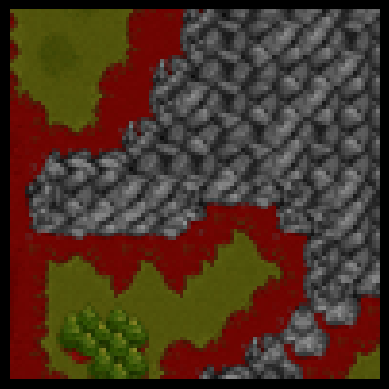

In [46]:
# unused 
from torchvision import transforms as transforms
import matplotlib.pyplot as plt
import torchvision
import torch

# aug_operator = transforms.ColorJitter(hue=0.1)
# tf = transforms.Compose(
#     [transforms.ToPILImage(), aug_operator, transforms.ToTensor()]
#     )
im_new = transforms.ColorJitter(hue=0.1)(im_pil)
# print(im_new)
# plt.imshow(im_pil)
plt.imshow(im_new)
# inputs[0]: 96, 96, 3
# tf: 3, 96, 96
# final: 96,96,3
# transformed = tf(torch.from_numpy(inputs[0]).permute(2,0,1)).permute(1,2,0)
# transformed_np = inv_norm(transformed, in_mean, in_std)[0].numpy()
# print(transformed_np)
# plt.imshow(transformed_np.astype(np.uint8))
# plt.imshow(transformed)
plt.axis('off')  # 关闭坐标轴
plt.show()    

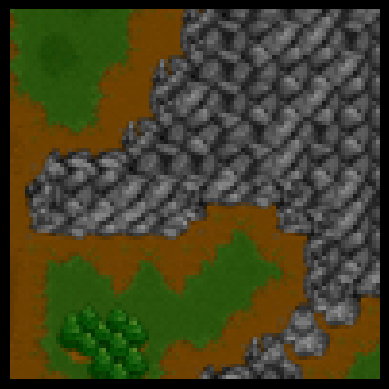

In [19]:
from torchvision import transforms as transforms
import matplotlib.pyplot as plt
import torchvision
import torch


plt.imshow(inv_norm(normed_inputs[0], in_mean, in_std)[0].numpy().astype(np.uint8))
plt.axis('off')  # 关闭坐标轴
plt.show()    

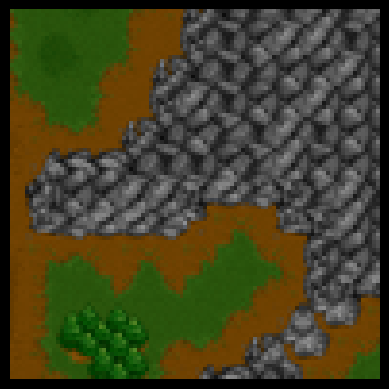

In [16]:
from torchvision import transforms as transforms
import matplotlib.pyplot as plt
import torchvision
import torch


plt.imshow(inputs[0].astype(np.uint8))
plt.axis('off')  # 关闭坐标轴
plt.show()

### augmentations

In [3]:
from PIL import Image
im_pil = Image.fromarray(inputs[0].astype(np.uint8), mode='RGB')

#### hue

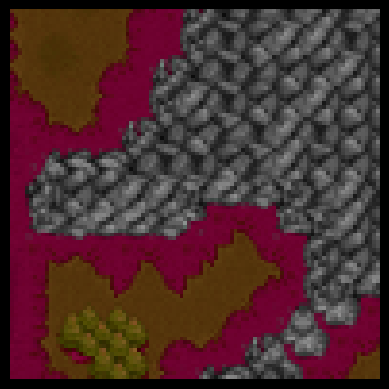

In [48]:

im_new = transforms.ColorJitter(hue=0.3)(im_pil)
plt.imshow(im_new)
plt.axis('off')  # 关闭坐标轴
plt.show()  

#### saturation

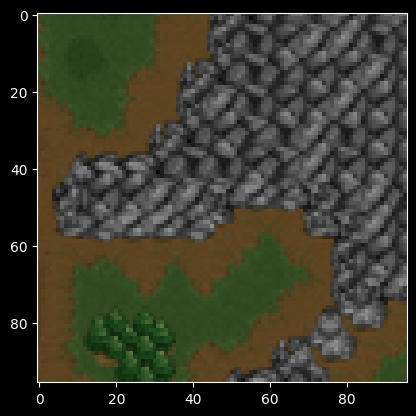

In [47]:
im_new = transforms.ColorJitter(saturation=3)(im_pil)
plt.imshow(im_new)

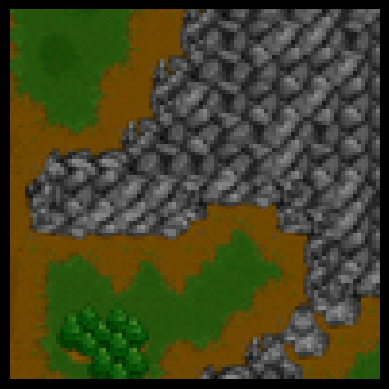

In [49]:
im_new = transforms.ColorJitter(hue=0.1)(im_pil)
plt.imshow(im_new)
plt.axis('off')  # 关闭坐标轴
plt.show()

#### contrast

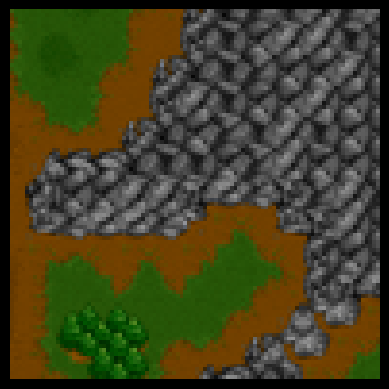

In [50]:
im_new = transforms.ColorJitter(contrast=0.1)(im_pil)
plt.imshow(im_new)
plt.axis('off')  # 关闭坐标轴
plt.show()

#### train

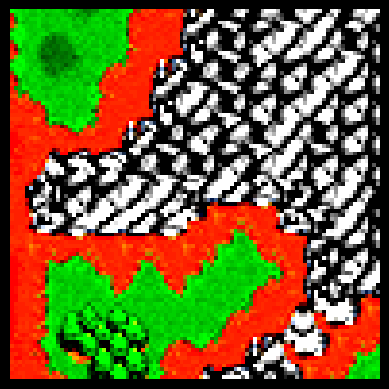

In [54]:
im_new = transforms.ColorJitter(contrast=10)(im_pil)
plt.imshow(im_new)
plt.axis('off')  # 关闭坐标轴
im_new.save("/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/sp_figs/train.pdf")
plt.show()

#### valid

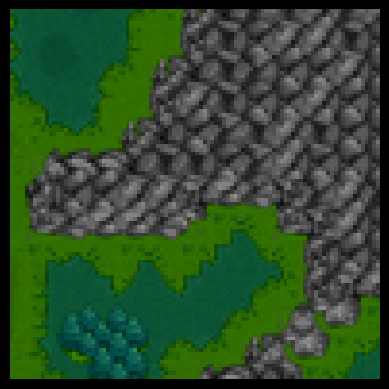

In [57]:
# from PIL import Image
# im_pil = Image.fromarray(inputs[0].astype(np.uint8), mode='RGB')
im_new = transforms.ColorJitter(hue=0.3)(im_pil)
plt.imshow(im_new)
plt.axis('off')  # 关闭坐标轴
im_new.save("/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/sp_figs/valid.pdf")
plt.show()  

#### test

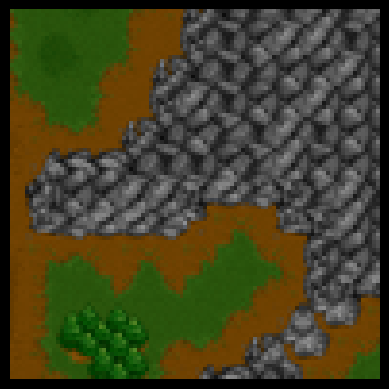

In [7]:
plt.imshow(inputs[0].astype(np.uint8))
plt.axis('off')  # 关闭坐标轴
im_pil.save("/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/sp_figs/test.pdf")
plt.show()